In [ ]:
from google.colab import drive
drive.mount('/content/drive')

rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
rm: cannot remove '/content/drive/.Encrypted/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Encrypted/MyDrive': Operation canceled
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

In [ ]:
latent_dim = 40

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )
    def forward(self, z):
        return self.net(z).view(-1,1,28,28)

encoder = Encoder().to(device)
decoder = Decoder().to(device)

optim_ae = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
loss_fn = nn.MSELoss()

In [ ]:
for epoch in range(3):
    for x, _ in train_loader:
        x = x.to(device)
        z = encoder(x)
        x_recon = decoder(z)

        loss = loss_fn(x_recon, x)

        optim_ae.zero_grad()
        loss.backward()
        optim_ae.step()

    print(f"AE epoch {epoch}, loss={loss.item():.4f}")

AE epoch 0, loss=0.0257
AE epoch 1, loss=0.0167
AE epoch 2, loss=0.0125


In [ ]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

clf = Classifier().to(device)
optim_clf = optim.Adam(clf.parameters(), lr=1e-3)
ce = nn.CrossEntropyLoss()

for epoch in range(2):
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        logits = clf(x)
        loss = ce(logits, y)

        optim_clf.zero_grad()
        loss.backward()
        optim_clf.step()

    print("clf epoch", epoch)

clf epoch 0
clf epoch 1


In [ ]:
def get_digit(digit):
    for x, y in train_dataset:
        if y == digit:
            return x.unsqueeze(0)

x2 = get_digit(2).to(device)
x6 = get_digit(6).to(device)

z2 = encoder(x2).detach()
z6 = encoder(x6).detach()

In [ ]:
def reward_fn(x,z):
    with torch.no_grad():
        logits = clf(x)
        probs = torch.softmax(logits, dim=-1)

        p2 = probs[:,2]
        p6 = probs[:,6]

        r = (p2 + p6) * (1 - torch.abs(p2 - p6))
        reg = 0.01 * torch.norm(z, dim=-1)
        return r

In [ ]:
class Policy(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 64),
            nn.ReLU(),
            nn.Linear(64, dim)
        )
        self.log_std = nn.Parameter(torch.zeros(dim))

    def sample(self, z):
        mu = self.net(z)
        std = torch.exp(self.log_std)

        dist = torch.distributions.Normal(mu, std)
        a = dist.rsample()
        logp = dist.log_prob(a).sum(-1)
        return a, logp

policy = Policy(latent_dim).to(device)
optim_policy = optim.Adam(policy.parameters(), lr=1e-3)

In [ ]:
def interpolate(z2, z6, alpha):
    return (1 - alpha) * z2 + alpha * z6

for epoch in range(500):

    alpha = torch.rand(1).to(device)
    z = interpolate(z2, z6, alpha)

    log_probs = []
    rewards = []

    for t in range(5):

        a, logp = policy.sample(z)
        z = (z + 0.1 * a).detach()

        x = decoder(z)
        r = reward_fn(x, z)

        log_probs.append(logp)
        rewards.append(r)

    log_probs = torch.stack(log_probs)
    rewards = torch.stack(rewards)

    baseline = rewards.mean()
    advantages = rewards - baseline

    loss = -(log_probs * advantages.detach()).mean()

    optim_policy.zero_grad()
    loss.backward()
    optim_policy.step()

    if epoch % 20 == 0:
        print(f"epoch {epoch}, reward={rewards.mean().item():.4f}")

epoch 0, reward=0.8081
epoch 20, reward=0.0393
epoch 40, reward=0.6854
epoch 60, reward=0.0282
epoch 80, reward=0.0724
epoch 100, reward=0.0361
epoch 120, reward=0.0356
epoch 140, reward=0.0232
epoch 160, reward=0.2708
epoch 180, reward=0.0327
epoch 200, reward=0.0258
epoch 220, reward=0.0234
epoch 240, reward=0.0263
epoch 260, reward=0.0925
epoch 280, reward=0.0239
epoch 300, reward=0.1681
epoch 320, reward=0.0420
epoch 340, reward=0.0041
epoch 360, reward=0.1565
epoch 380, reward=0.0276
epoch 400, reward=0.0958
epoch 420, reward=0.0330
epoch 440, reward=0.0391
epoch 460, reward=0.3457
epoch 480, reward=0.0404


In [ ]:
best_reward = -float("inf")
best_state_dict = None

reward_threshold = 0.89   # 你可以调
patience = 50           # 防止过早停止
no_improve_count = 0

for epoch in range(1000):

    alpha = torch.rand(1).to(device)
    z = interpolate(z2, z6, alpha)

    log_probs = []
    rewards = []

    for t in range(5):

        a, logp = policy.sample(z)
        z = (z + 0.1 * a).detach()

        x = decoder(z)
        r = reward_fn(x, z)

        log_probs.append(logp)
        rewards.append(r)

    log_probs = torch.stack(log_probs)
    rewards = torch.stack(rewards)

    mean_reward = rewards.mean()

    baseline = mean_reward
    advantages = rewards - baseline

    loss = -(log_probs * advantages.detach()).mean()

    optim_policy.zero_grad()
    loss.backward()
    optim_policy.step()

    # ====== (1) 记录 best ======
    if mean_reward.item() > best_reward:
        best_reward = mean_reward.item()
        best_state_dict = policy.state_dict()
        no_improve_count = 0
    else:
        no_improve_count += 1

    # ====== (2) early stopping ======
    if mean_reward.item() > reward_threshold:
        print(f"Early stop at epoch {epoch}, reward={mean_reward.item():.4f}")
        break

    if no_improve_count > patience:
        print(f"Stop due to no improvement at epoch {epoch}")
        break

    if epoch % 25 == 0:
        print(f"epoch {epoch}, reward={mean_reward.item():.4f}")

# ====== (3) 恢复 best policy ======
if best_state_dict is not None:
    policy.load_state_dict(best_state_dict)
    print(f"Loaded best policy with reward={best_reward:.4f}")

epoch 0, reward=0.3790
epoch 25, reward=0.0247
epoch 50, reward=0.3446
epoch 75, reward=0.0340
epoch 100, reward=0.1091
epoch 125, reward=0.0985
epoch 150, reward=0.0013
epoch 175, reward=0.0366
Stop due to no improvement at epoch 196
Loaded best policy with reward=0.8744


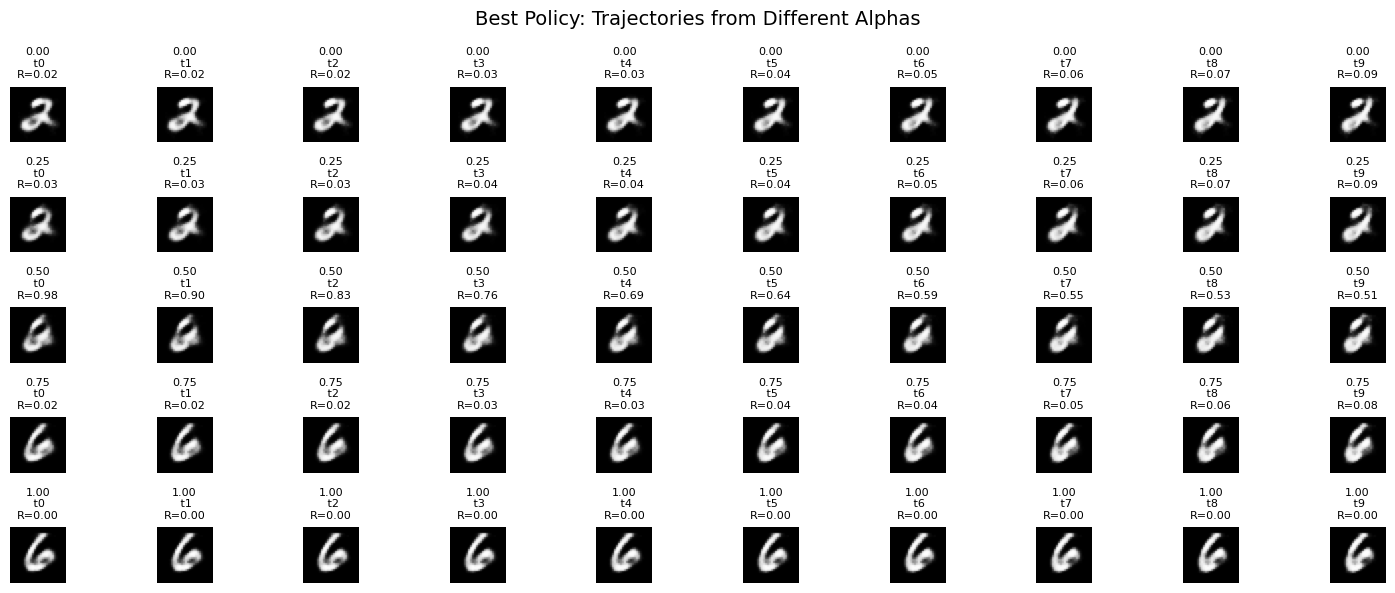

In [ ]:
# ===== 使用 best policy 做系统性可视化 =====

policy.eval()

alphas = torch.linspace(0, 1, steps=5).to(device)
T = 10

fig, axes = plt.subplots(len(alphas), T, figsize=(15, 6))

all_rewards = []

for row, alpha in enumerate(alphas):

    z = interpolate(z2, z6, alpha.unsqueeze(0))
    traj_rewards = []

    for t in range(T):

        x = decoder(z)
        r = reward_fn(x, z)
        traj_rewards.append(r.item())

        ax = axes[row, t] if len(alphas) > 1 else axes[t]
        ax.imshow(x.squeeze().cpu().detach(), cmap='gray')
        ax.set_title(f"{alpha.item():.2f}\n t{t}\nR={r.item():.2f}", fontsize=8)
        ax.axis('off')

        # ===== deterministic policy（关键）=====
        with torch.no_grad():
            a = policy.net(z)

        # ===== 保持训练一致 =====
        z = z + 0.1 * a

    all_rewards.append(traj_rewards)

plt.suptitle("Best Policy: Trajectories from Different Alphas", fontsize=14)
plt.tight_layout()
plt.show()

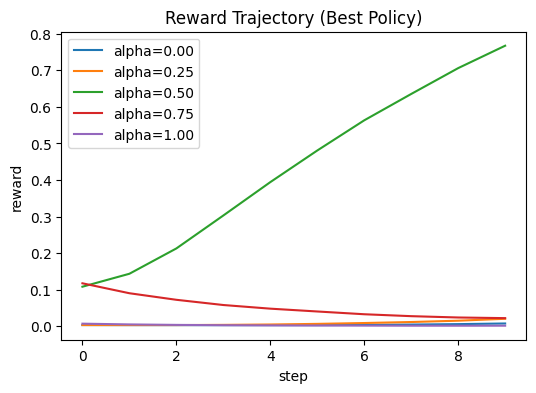

In [ ]:
# ===== reward trajectory plot =====

plt.figure(figsize=(6,4))

for i, traj in enumerate(all_rewards):
    plt.plot(traj, label=f'alpha={alphas[i].item():.2f}')

plt.xlabel("step")
plt.ylabel("reward")
plt.title("Reward Trajectory (Best Policy)")
plt.legend()
plt.show()